<a href="https://colab.research.google.com/github/wonzzae/WJ-Archive/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EA%B4%80%EB%A6%AC%EB%A1%A0%203%EC%9B%94%20%EA%B3%BC%EC%A0%9C/3%EC%9B%94_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 피마 인디언 당뇨병 예측을 위한 탐색적 데이터 분석(EDA) 보고서

## 1. 서론 (Introduction)

**1.1 분석 배경 및 목적**
* 당뇨병은 전 세계적으로 심각한 건강 문제 중 하나이며, 조기 진단과 예방이 필수적입니다.
* 본 분석의 목적은 환자의 임상 데이터를 바탕으로 당뇨병 발병 여부에 영향을 미치는 주요 요인을 파악하고, 각 변수 간의 관계를 탐색하는 것입니다.

**1.2 데이터 셋 설명**
* [cite_start]**출처:** 국립 당뇨병·소화기·신장 질환 연구소(National Institute of Diabetes and Digestive and Kidney Diseases) 제공[cite: 1].
* [cite_start]**대상:** 미국 애리조나주 피닉스 근처에 거주하는 [cite: 8] [cite_start]21세 이상의 피마 인디언 여성 환자[cite: 11].
* [cite_start]**구성:** 8개의 수치형 의료 기록 변수(임신 횟수, 포도당 내성, 혈압 등)와 1개의 타겟 변수(당뇨 여부)로 구성됨[cite: 14]. [cite_start]타겟 변수는 'tested_positive(당뇨)'와 'tested_negative(정상)'로 분류됨[cite: 19].

**1.3 주요 분석 질문 (Key Questions)**
* **가설 1:** 포도당(Glucose) 수치가 높을수록 당뇨 발병 확률이 높을 것이다.
* **가설 2:** 체질량지수(BMI)와 연령(Age)은 당뇨 발병과 유의미한 양의 상관관계를 가질 것이다.

In [ ]:
# 라이브러리 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

# 폰트 깨짐 방지 (Colab 한글 설정)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 데이터 불러오기 (.arff 형식 처리)
# 좌측 파일 탭에 'dataset_37_diabetes.arff' 파일이 업로드되어 있어야 합니다.
data = arff.loadarff('dataset_37_diabetes.arff')
df = pd.DataFrame(data[0])

# 바이트 문자열로 되어 있는 타겟 변수를 일반 문자열로 디코딩
df['class'] = df['class'].str.decode('utf-8')
df.head()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (43.5 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direct

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,tested_positive
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,tested_negative
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,tested_positive
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,tested_negative
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,tested_positive


## 2. 데이터 프로파일링 및 기초 탐색 (Data Profiling)

**2.1 데이터 명세 확인**
* 총 레코드 수와 컬럼을 확인하고 데이터 타입을 점검합니다.

**2.2 결측치 분석 및 2.4 데이터 정제(Cleaning)**
* 이 데이터셋은 표면적으로는 결측치가 없으나, 생물학적으로 0이 될 수 없는 값(포도당 수치, 혈압, 피부 두께, 인슐린, 체질량 지수)에 0이 포함되어 있습니다. 이는 누락된 데이터(결측치)를 의미하므로 이를 `NaN`으로 변환한 뒤, 각 변수의 중앙값(Median)으로 대체(Imputation)하였습니다.

**2.3 기초 통계량 분석**
* (코드 실행 후 결과를 바탕으로 기초 통계량을 확인합니다.)

데이터 형태: (768, 9)

[데이터 정보]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    float64
 1   plas    768 non-null    float64
 2   pres    768 non-null    float64
 3   skin    768 non-null    float64
 4   insu    768 non-null    float64
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    float64
 8   class   768 non-null    object 
dtypes: float64(8), object(1)
memory usage: 54.1+ KB


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

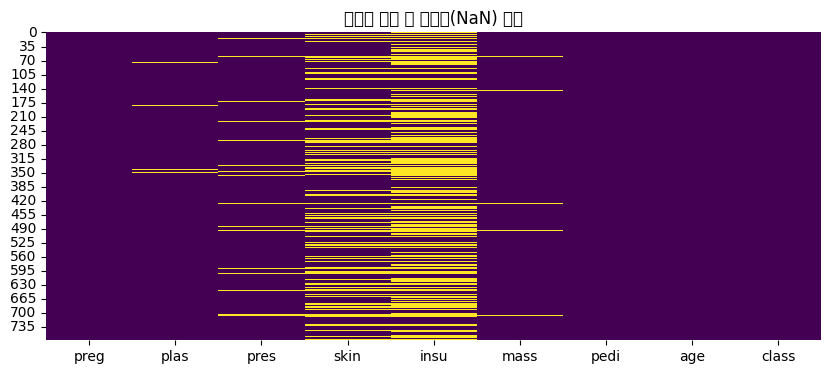

,preg,plas,pres,skin,insu,mass,pedi,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [ ]:
# 2.1 데이터 명세 확인
print("데이터 형태:", df.shape)
print("\n[데이터 정보]")
df.info()

# 2.2 & 2.4 이상치(0값)를 NaN으로 변경 및 중앙값 대체
# 임신 횟수(preg)를 제외한 변수들에서 0은 결측치를 의미함
cols_with_zero = ['plas', 'pres', 'skin', 'insu', 'mass']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

# 결측치 시각화
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('데이터 정제 전 결측치(NaN) 분포')
plt.show()

# 타겟 변수(class)별 중앙값으로 결측치 대체
for col in cols_with_zero:
    df[col] = df[col].fillna(df.groupby('class')[col].transform('median'))

# 2.3 데이터 정제 후 기초 통계량 확인
display(df.describe())

## 3. 변수별 개별 특성 분석 (Univariate Analysis)

**3.1 수치형 변수 분석 및 3.2 범주형 변수 분석**
* 주요 수치형 변수(포도당 수치, 연령 등)의 분포를 확인합니다.
* 종속 변수(Class)의 분포를 확인하여 데이터 불균형 여부를 파악합니다.

**3.3 파생 변수 생성 (Feature Engineering)**
* 나이(Age) 변수를 활용하여 연령대별 그룹(Age_Group) 파생 변수를 생성했습니다.

/tmp/ipykernel_291/3161561376.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette='Set2')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45544 (\N{HANGUL SYLLABLE NYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48337 (\N{HANGUL SYLLABLE BYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) miss

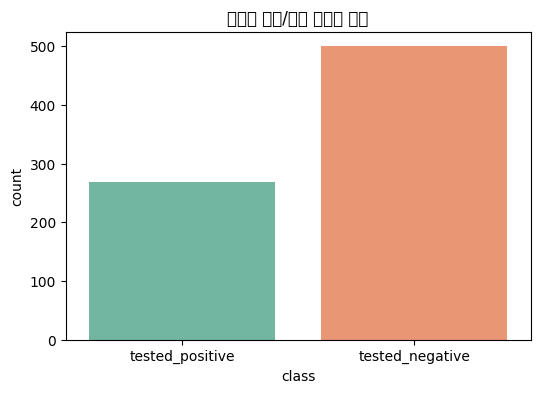

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

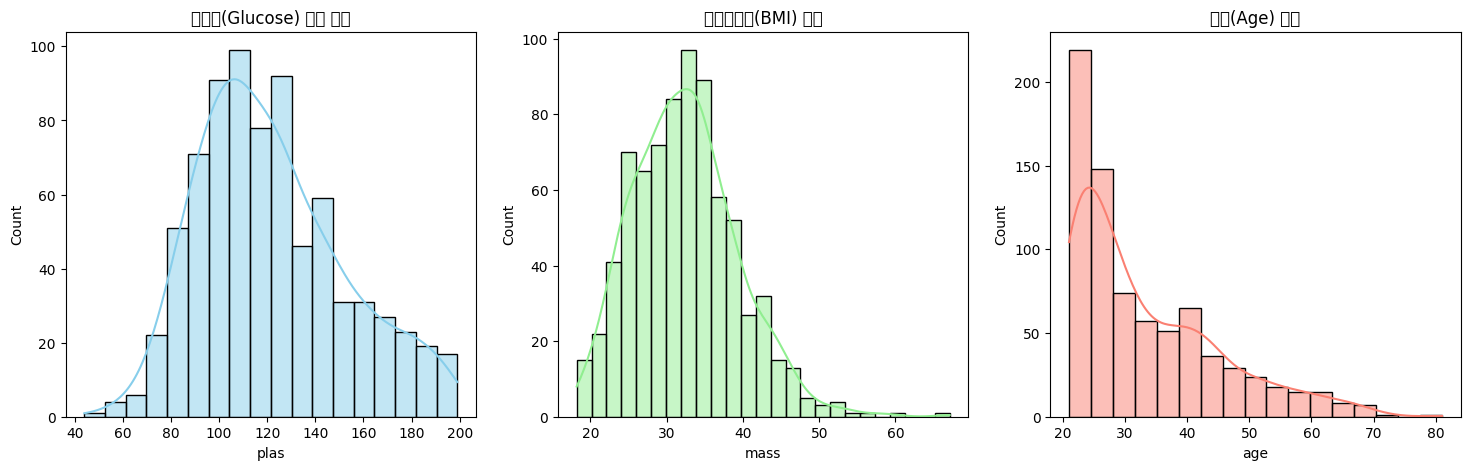

In [ ]:
# 3.2 타겟 범주형 변수 분포 확인
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', palette='Set2')
plt.title('당뇨병 양성/음성 데이터 분포')
plt.show()

# 3.1 주요 수치형 변수 분포 (포도당 수치, BMI, 연령)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['plas'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('포도당(Glucose) 수치 분포')

sns.histplot(df['mass'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('체질량지수(BMI) 분포')

sns.histplot(df['age'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('연령(Age) 분포')
plt.show()

# 3.3 파생 변수 생성: 연령대 그룹화 (Binning)
bins = [20, 30, 40, 50, 60, 100]
labels = ['20대', '30대', '40대', '50대', '60대 이상']
df['Age_Group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

## 4. 상관관계 및 관계 분석 (Multivariate Analysis)

**4.1 수치형 변수 간 상관관계**
* 독립 변수들 간의 다중공선성을 확인하고, 타겟 변수와 밀접한 관련이 있는 변수를 탐색합니다.

**4.2 타겟 변수 기반 심층 분석 & 4.3 세그먼트별 분석**
* 당뇨 여부에 따른 주요 수치 변화를 시각화합니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

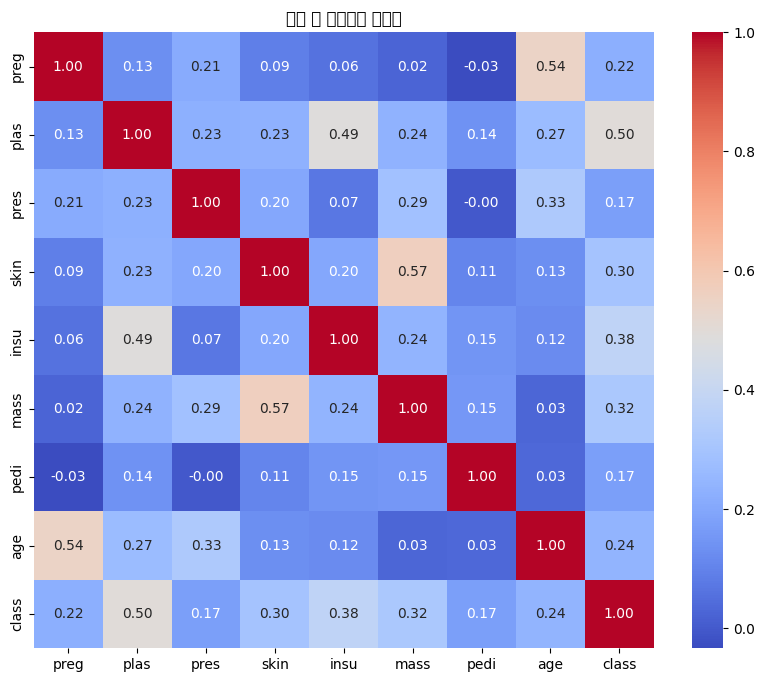

/tmp/ipykernel_291/9658140.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y='plas', ax=axes[0], palette='Pastel1')
/tmp/ipykernel_291/9658140.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y='mass', ax=axes[1], palette='Pastel2')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45544 (\N{HANGUL SYLLABLE NYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/py

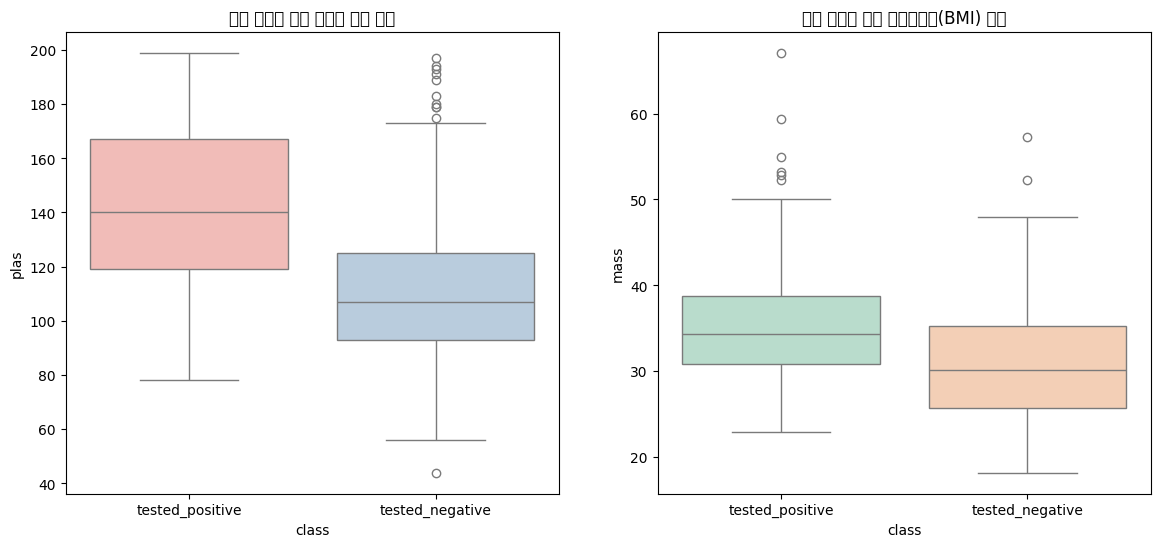

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

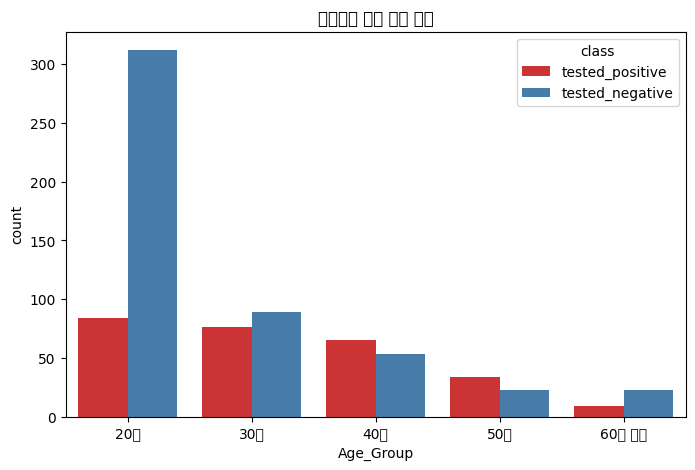

In [ ]:
# 타겟 변수를 수치형(0과 1)으로 잠시 변환하여 상관관계 계산
df_corr = df.copy()
df_corr['class'] = df_corr['class'].map({'tested_negative': 0, 'tested_positive': 1})

# 4.1 수치형 변수 간 상관관계 히트맵
plt.figure(figsize=(10, 8))
# Age_Group과 같은 파생 범주형 변수 제외
numeric_df = df_corr.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('변수 간 상관관계 히트맵')
plt.show()

# 4.2 타겟 변수별 주요 수치 분포 차이 (Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=df, x='class', y='plas', ax=axes[0], palette='Pastel1')
axes[0].set_title('당뇨 여부에 따른 포도당 수치 차이')

sns.boxplot(data=df, x='class', y='mass', ax=axes[1], palette='Pastel2')
axes[1].set_title('당뇨 여부에 따른 체질량지수(BMI) 차이')
plt.show()

# 4.3 세그먼트별 비교: 연령대별 당뇨 양성 비율
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Age_Group', hue='class', palette='Set1')
plt.title('연령대별 당뇨 발병 현황')
plt.show()

## 5. 핵심 인사이트 및 가설 검정 (Key Insights)

**5.1 주요 패턴 발견**
* [작성 가이드: 위 Boxplot 그래프를 보고 포도당 수치 평균이 양성/음성에 따라 어떻게 다른지 적어주세요. 예: 시각화 결과, 당뇨 양성 환자들의 포도당 수치가 음성 환자에 비해 전반적으로 높게 분포되어 있음을 확인했습니다.]
* [작성 가이드: 연령대별 그래프를 보고 어느 연령대에서 당뇨 환자가 제일 많은지 적어주세요.]

**5.2 가설 검증 결과**
* **가설 1 검증:** [채택/기각 여부 적기. 상관관계 히트맵의 숫자를 언급하면 좋습니다.]
* **가설 2 검증:** [채택/기각 여부 적기.]

**5.3 예상치 못한 발견**
* [작성 가이드: 히트맵을 보고 생각보다 상관관계가 낮았던 변수가 있다면 적어주세요. 예: 피부 두께와 인슐린 수치의 상관관계가 생각보다 높게/낮게 나타났다.]

## 6. 결론 및 향후 방향 (Conclusion & Recommendation)

**6.1 분석 요약**
* 피마 인디언 여성의 당뇨 발병 여부에는 수많은 생리학적 변수 중에서도 [가장 상관관계가 높았던 변수 1~2개 이름]가 가장 결정적인 영향을 미치는 것으로 파악됩니다.

**6.2 비즈니스(의료) 제언**
* **예방 목적:** 고위험군으로 분류되는 [가장 발병률이 높은 나이대/체중 등] 환자들을 대상으로 정기적인 포도당 내성 검사를 권고해야 합니다.
* **데이터 수집:** 이번 데이터 정제 과정에서 인슐린, 피부 두께 등의 항목에 누락값(0)이 많았으므로, 향후 병원에서 데이터 수집 시 누락을 방지하는 프로세스 개선이 필요합니다.

**6.3 한계점 및 추후 과제**
* 본 데이터는 특정 지역의 여성만을 대상으로 수집되었으므로, 다른 인종이나 남성에게 일반화하기 어렵다는 샘플링 편향의 한계가 있습니다.
* 향후 Random Forest나 XGBoost 같은 머신러닝 분류 모델을 도입하여 실제 당뇨 발병 여부를 예측하는 모델을 구축해 볼 수 있습니다.